# Cav1.2 G406R nearby-mutation distance analysis
WT and G406R ensembles are compared separately for vanilla and masked protocols using the largest median shifts among distance columns within ±4 residues of G406.

The final section analyzes shortest heavy-atom distances made by the introduced R406 side chain. Candidate acidic contacts are shown alongside R406–T1531, whose sub-2 Å population is explicitly treated as probable atomic overlap rather than a biological interaction.


In [4]:
from pathlib import Path
import importlib
import sys
repo_root = Path.cwd() if (Path.cwd() / 'shared').is_dir() else Path.cwd().parent
sys.path.insert(0, str(repo_root)) if str(repo_root) not in sys.path else None
import shared.mutation_site_analysis as mutation_site_analysis
importlib.reload(mutation_site_analysis)  # Pick up helper changes in an already-running kernel.
load_ensemble = mutation_site_analysis.load_ensemble
nearby_distance_columns = mutation_site_analysis.nearby_distance_columns
rank_nearby_shifts = mutation_site_analysis.rank_nearby_shifts
top_aliases = mutation_site_analysis.top_aliases
plot_nearby_overlay = mutation_site_analysis.plot_nearby_overlay
from shared.dataset_selection import distance_csv_options, load_selected_distance_csv
CAV12_PALETTE = {'WT_VAN':'#DCEBF8','WT_HM':'#5E98CB','G406R_VAN':'#C8DAF6','G406R_HM':'#4B77C8'}
G406R_EXPERIMENTAL_DISTANCES = {
    '8WE6 | chain A': {
        'CA_LEU401_CA-ILE1186_CA': [10.070], 'CA_LEU401_CA-VAL753_CA': [11.718],
        'CA_GLU407_CA-ARG1532_CA': [9.716], 'CA_GLU407_CA-LEU1530_CA': [7.270], 'CA_GLU407_CA-THR1531_CA': [6.724],
        'CA_PHE408_CA-ARG1532_CA': [12.668], 'CA_PHE408_CA-THR1531_CA': [9.273], 'GLU407-ARG1532': [8.011],
        'GLU407-ASP1533': [9.304], 'GLU407-TYR1529': [8.236], 'LEU404-ARG1532': [11.220],
        'PHE408-ARG1532': [10.269], 'PHE408-TRP1534': [13.153], 'SER405-ARG1532': [9.744],
    },
    '8HLP | chain A': {
        'CA_LEU401_CA-ILE1186_CA': [9.986], 'CA_LEU401_CA-VAL753_CA': [11.751],
        'CA_GLU407_CA-ARG1532_CA': [8.687], 'CA_GLU407_CA-LEU1530_CA': [7.352], 'CA_GLU407_CA-THR1531_CA': [6.392],
        'CA_PHE408_CA-ARG1532_CA': [11.595], 'CA_PHE408_CA-THR1531_CA': [8.828], 'GLU407-ARG1532': [7.179],
        'GLU407-ASP1533': [8.362], 'GLU407-TYR1529': [7.913], 'LEU404-ARG1532': [10.248],
        'PHE408-ARG1532': [9.330], 'PHE408-TRP1534': [12.814], 'SER405-ARG1532': [9.122],
    },
    '8FD7 | chain K': {
        'CA_LEU401_CA-ILE1186_CA': [13.653], 'CA_LEU401_CA-VAL753_CA': [15.182],
        'CA_GLU407_CA-ARG1532_CA': [11.739], 'CA_GLU407_CA-LEU1530_CA': [10.872], 'CA_GLU407_CA-THR1531_CA': [8.756],
        'CA_PHE408_CA-ARG1532_CA': [8.953], 'CA_PHE408_CA-THR1531_CA': [6.103], 'GLU407-ARG1532': [9.949],
        'GLU407-ASP1533': [10.982], 'GLU407-TYR1529': [11.953], 'LEU404-ARG1532': [8.867],
        'PHE408-ARG1532': [5.747], 'PHE408-TRP1534': [10.327], 'SER405-ARG1532': [6.412],
    },
}
G406R_EXPERIMENTAL_DISTANCES


{'8WE6 | chain A': {'CA_LEU401_CA-ILE1186_CA': [10.07],
  'CA_LEU401_CA-VAL753_CA': [11.718],
  'CA_GLU407_CA-ARG1532_CA': [9.716],
  'CA_GLU407_CA-LEU1530_CA': [7.27],
  'CA_GLU407_CA-THR1531_CA': [6.724],
  'CA_PHE408_CA-ARG1532_CA': [12.668],
  'CA_PHE408_CA-THR1531_CA': [9.273],
  'GLU407-ARG1532': [8.011],
  'GLU407-ASP1533': [9.304],
  'GLU407-TYR1529': [8.236],
  'LEU404-ARG1532': [11.22],
  'PHE408-ARG1532': [10.269],
  'PHE408-TRP1534': [13.153],
  'SER405-ARG1532': [9.744]},
 '8HLP | chain A': {'CA_LEU401_CA-ILE1186_CA': [9.986],
  'CA_LEU401_CA-VAL753_CA': [11.751],
  'CA_GLU407_CA-ARG1532_CA': [8.687],
  'CA_GLU407_CA-LEU1530_CA': [7.352],
  'CA_GLU407_CA-THR1531_CA': [6.392],
  'CA_PHE408_CA-ARG1532_CA': [11.595],
  'CA_PHE408_CA-THR1531_CA': [8.828],
  'GLU407-ARG1532': [7.179],
  'GLU407-ASP1533': [8.362],
  'GLU407-TYR1529': [7.913],
  'LEU404-ARG1532': [10.248],
  'PHE408-ARG1532': [9.33],
  'PHE408-TRP1534': [12.814],
  'SER405-ARG1532': [9.122]},
 '8FD7 | chain K': {

In [5]:
DATASET_SELECTION = 'all_ok_3'  # Corrected 3 Å convergence subset generated from the complete 2026-07-25 G406R tables.
data = repo_root / 'cav12' / 'dataDistances'
DATASET_PATHS = {
    'WT vanilla': distance_csv_options(repo_root, data / '26-02-10_Cav12_wt_vanillaAF2_distances_all.csv', 'Cav12', 'WT', 'vanilla'),
    'WT masked': distance_csv_options(repo_root, data / '26-02-10_Cav12_wt_maskedAF2_distances_all.csv', 'Cav12', 'WT', 'masked'),
    'G406R vanilla': distance_csv_options(repo_root, data / '26-07-25_Cav1.2_g406r_vanillaAF2_distances_all.csv', 'Cav12', 'G406R', 'vanilla'),
    'G406R masked': distance_csv_options(repo_root, data / '26-07-25_Cav1.2_g406r_maskedAF2_distances_all.csv', 'Cav12', 'G406R', 'masked'),
}
DATASET_PATHS
wt_van = load_selected_distance_csv('WT vanilla', DATASET_PATHS['WT vanilla'], DATASET_SELECTION)
wt_mask = load_selected_distance_csv('WT masked', DATASET_PATHS['WT masked'], DATASET_SELECTION)
mut_van = load_selected_distance_csv('G406R vanilla', DATASET_PATHS['G406R vanilla'], DATASET_SELECTION)
mut_mask = load_selected_distance_csv('G406R masked', DATASET_PATHS['G406R masked'], DATASET_SELECTION)
structures = {'8WE6 | chain A': (repo_root / 'cav12' / 'experimentals' / '8WE6.pdb', 'A'), '8HLP | chain A': (repo_root / 'cav12' / 'experimentals' / '8HLP.pdb', 'A'), '8FD7 | chain K': (repo_root / 'cav12' / 'experimentals' / '8FD7.pdb', 'K')}
experimental_colors = {'8WE6 | chain A':'#D55E00','8HLP | chain A':'#0072B2','8FD7 | chain K':'#009E73'}


WT vanilla: requested=all_ok_3; actual=all_ok_3; path=/Users/ahernandezgonzalez/Repositories/vgci_mutants/cav12/dataDistances/26-02-10_Cav12_wt_vanillaAF2_distances_all_ok_rmsd_3A.csv
WT masked: requested=all_ok_3; actual=all_ok_3; path=/Users/ahernandezgonzalez/Repositories/vgci_mutants/cav12/dataDistances/26-02-10_Cav12_wt_maskedAF2_distances_all_ok_rmsd_3A.csv
G406R vanilla: requested=all_ok_3; actual=all_ok_3; path=/Users/ahernandezgonzalez/Repositories/vgci_mutants/cav12/dataDistances/26-07-25_Cav1.2_g406r_vanillaAF2_distances_all_ok_rmsd_3A.csv
G406R masked: requested=all_ok_3; actual=all_ok_3; path=/Users/ahernandezgonzalez/Repositories/vgci_mutants/cav12/dataDistances/26-07-25_Cav1.2_g406r_maskedAF2_distances_all_ok_rmsd_3A.csv


,distance,wt_median_A,mutant_median_A,median_shift_A,abs_shift_A
81,shortest_GLU407-ARG1532,11.20,13.10,1.90,1.90
47,shortest_LEU404-ARG1532,15.30,17.20,1.90,1.90
64,shortest_SER405-ARG1532,9.10,10.80,1.70,1.70
82,shortest_GLU407-ASP1533,8.70,7.30,-1.40,1.40
183,CA_GLU407_CA-ARG1532_CA,8.92,10.28,1.36,1.36
100,shortest_PHE408-TRP1534,23.20,24.50,1.30,1.30
79,shortest_GLU407-LEU1530,13.50,14.80,1.30,1.30
182,CA_GLU407_CA-THR1531_CA,9.26,10.54,1.28,1.28
200,CA_PHE408_CA-ARG1532_CA,11.93,13.19,1.26,1.26
199,CA_PHE408_CA-THR1531_CA,12.65,13.89,1.24,1.24


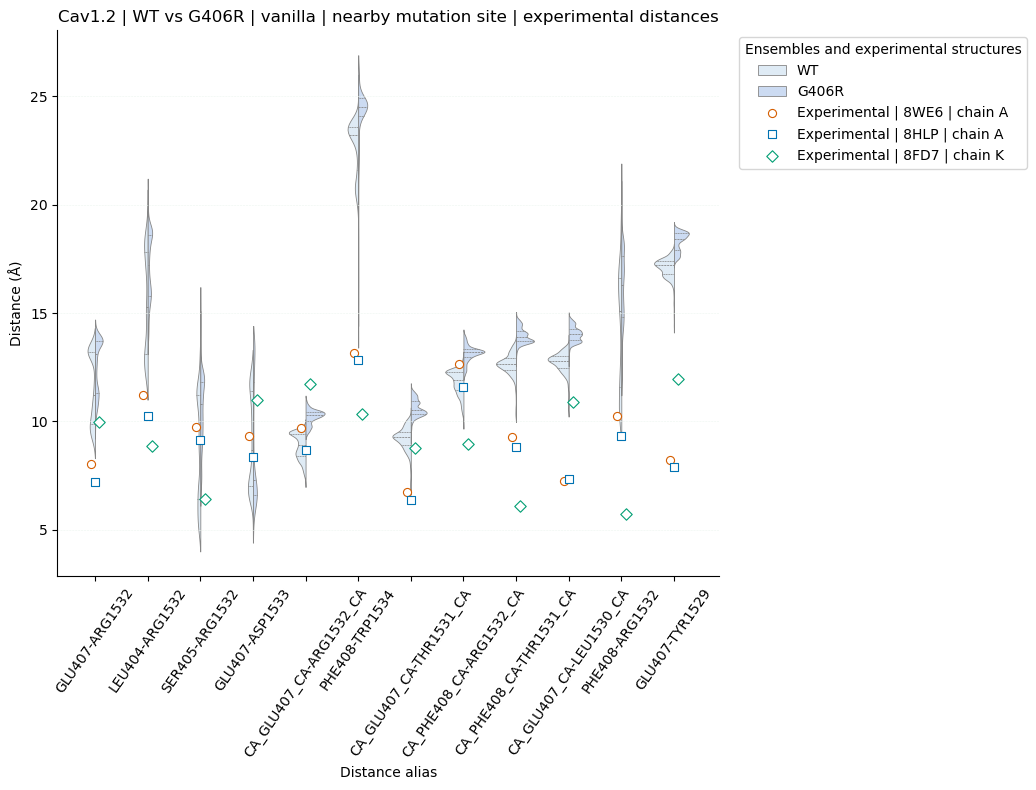

,distance,wt_median_A,mutant_median_A,median_shift_A,abs_shift_A
99,shortest_PHE408-ASP1533,20.50,17.20,-3.30,3.30
82,shortest_GLU407-ASP1533,12.20,9.10,-3.10,3.10
48,shortest_LEU404-ASP1533,19.10,16.60,-2.50,2.50
98,shortest_PHE408-ARG1532,16.70,18.60,1.90,1.90
64,shortest_SER405-ARG1532,10.20,12.00,1.80,1.80
47,shortest_LEU404-ARG1532,17.00,18.50,1.50,1.50
182,CA_GLU407_CA-THR1531_CA,9.28,10.48,1.20,1.20
81,shortest_GLU407-ARG1532,12.50,13.70,1.20,1.20
199,CA_PHE408_CA-THR1531_CA,12.68,13.86,1.18,1.18
181,CA_GLU407_CA-LEU1530_CA,12.86,13.96,1.10,1.10


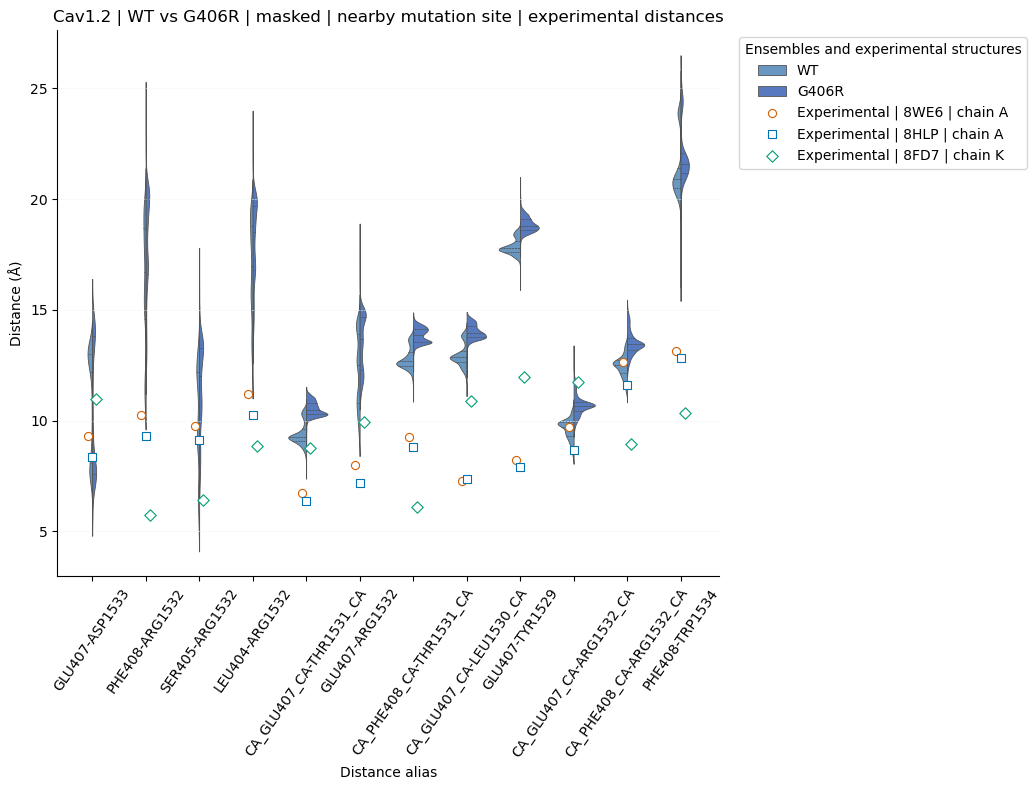

In [6]:
for protocol, wt, mutant, colors in [('vanilla', wt_van, mut_van, (CAV12_PALETTE['WT_VAN'], CAV12_PALETTE['G406R_VAN'])), ('masked', wt_mask, mut_mask, (CAV12_PALETTE['WT_HM'], CAV12_PALETTE['G406R_HM']))]:
    shifts = rank_nearby_shifts(wt, mutant, nearby_distance_columns(wt, 406))
    display(shifts.head(20))
    if shifts.empty:
        print(f'Skipping {protocol}: no mutation-site distance columns contain values in both WT and G406R ensembles.')
        continue
    experimental_aliases = set(next(iter(G406R_EXPERIMENTAL_DISTANCES.values())))
    shifts = shifts[shifts['distance'].map(lambda column: column.replace('CA_CA_', '').replace('shortest_', '') in experimental_aliases)]
    if shifts.empty:
        print(f'Skipping {protocol}: none of the comparable columns has an explicit experimental distance.')
        continue
    aliases = top_aliases(shifts, n=len(experimental_aliases))
    experimentals = {structure: {alias: values for alias, values in distances.items() if alias in aliases} for structure, distances in G406R_EXPERIMENTAL_DISTANCES.items()}
    plot_nearby_overlay(wt, mutant, aliases, 'Cav1.2', 'G406R', protocol, colors, experimentals, experimental_colors)

## Contacts made by the introduced R406 side chain
from shared.mutation_contact_analysis import plot_mutation_contacts, plot_selected_contact_distributions
g406r_contact_table, _ = plot_mutation_contacts(
    {'vanilla': (wt_van, mut_van), 'masked': (wt_mask, mut_mask)},
    'GLY406', 'ARG406', 'G406R',
    {'vanilla': CAV12_PALETTE['G406R_VAN'], 'masked': CAV12_PALETTE['G406R_HM']},
)
display(g406r_contact_table.head(15).round(3))
plot_selected_contact_distributions(
    {'vanilla': (wt_van, mut_van), 'masked': (wt_mask, mut_mask)},
    'GLY406', 'ARG406', 'G406R', ['THR1531', 'ASP1528', 'ASP1533'],
    {'vanilla': (CAV12_PALETTE['WT_VAN'], CAV12_PALETTE['G406R_VAN']), 'masked': (CAV12_PALETTE['WT_HM'], CAV12_PALETTE['G406R_HM'])},
)
